 installing the required modules

In [2]:
pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


Importing the modules

In [3]:
import pandas as pan
import matplotlib.pyplot as mplot

Importing the raw data

In [4]:
df_raw = pan.read_csv("drsi.csv")

Eploring the data set 

In [5]:
print(df_raw.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 653 entries, 0 to 652
Columns: 622 entries, Title to 47.30: Implied Deflator Index: Predominantly automotive fuel
dtypes: object(622)
memory usage: 3.1+ MB
None


In [6]:
print(df_raw.head())

          Title  \
0          CDID   
1       PreUnit   
2          Unit   
3  Release Date   
4  Next release   

  Implied deflator:AGG 1:Pred food stores - month on previous month%  \
0                                               A4RT                   
1                                                NaN                   
2                                                  %                   
3                                         20-02-2026                   
4                                      27 March 2026                   

  Implied deflator:AGG 12:Pred non-food stores - month on previous month%  \
0                                               A4RU                        
1                                                NaN                        
2                                                  %                        
3                                         20-02-2026                        
4                                      27 March 2026               

Checking the 'Title' column and a few data columns to see the range and format

In [7]:
print(df_raw['Title'].head())
print(df_raw['Title'].tail())

0            CDID
1         PreUnit
2            Unit
3    Release Date
4    Next release
Name: Title, dtype: object
648    2025 SEP
649    2025 OCT
650    2025 NOV
651    2025 DEC
652    2026 JAN
Name: Title, dtype: object


Checking for any non-numeric values in some data columns taking first 20 colums

In [8]:
Sample_20=df_raw.columns[:20]
print(df_raw[Sample_20].head())
print(df_raw[Sample_20].tail())

          Title  \
0          CDID   
1       PreUnit   
2          Unit   
3  Release Date   
4  Next release   

  Implied deflator:AGG 1:Pred food stores - month on previous month%  \
0                                               A4RT                   
1                                                NaN                   
2                                                  %                   
3                                         20-02-2026                   
4                                      27 March 2026                   

  Implied deflator:AGG 12:Pred non-food stores - month on previous month%  \
0                                               A4RU                        
1                                                NaN                        
2                                                  %                        
3                                         20-02-2026                        
4                                      27 March 2026               

Selecting paticular columns for the analysis and renaming for standrdazation
Title: Period,
RSI:Predominantly food stores (val nsa):All Business Index: Food_Stores,
RSI:textiles, clothing & footwear (val nsa):All Business Index: Clothing_Footwear,
RSI:Household goods stores (val nsa):All Business Index: Household_Goods,
Internet sales as a percentage of total retail sales (ratio) (%): Internet_Share


In [9]:
column_mapping = ({
    'Title': 'Period',
    'RSI:Predominantly food stores (val nsa):All Business Index': 'Food_Stores',
    'RSI:textiles, clothing & footwear (val nsa):All Business Index': 'Clothing_Footwear',
    'RSI:Household goods stores (val nsa):All Business Index': 'Household_Goods',
    'Internet sales as a percentage of total retail sales (ratio) (%)': 'Internet_Share'
})
req_col = df_raw[list(column_mapping.keys())].rename(columns=column_mapping)
req_col.head()

,Period,Food_Stores,Clothing_Footwear,Household_Goods,Internet_Share
0,CDID,EAFS,EAFU,EAFV,J4MC
1,PreUnit,NaN,NaN,NaN,NaN
2,Unit,NaN,NaN,NaN,%
3,Release Date,20-02-2026,20-02-2026,20-02-2026,20-02-2026
4,Next release,27 March 2026,27 March 2026,27 March 2026,27 March 2026


dropping the unnecessory rows and creating a copy of data with actual numerical data

In [10]:
req_col=req_col.iloc[6:].copy()
req_col

,Period,Food_Stores,Clothing_Footwear,Household_Goods,Internet_Share
6,1988,23.7,32.7,50.6,NaN
7,1989,25.5,35.0,53.0,NaN
8,1990,27.7,37.6,54.7,NaN
9,1991,29.8,37.5,54.5,NaN
10,1992,31.5,37.6,54.2,NaN
...,...,...,...,...,...
648,2025 SEP,102.6,103.2,95.1,27.2
649,2025 OCT,104.4,104.3,104.8,27.9
650,2025 NOV,108.9,121.6,117.7,32.3
651,2025 DEC,118.3,139.5,97.9,29.4


Filtering the data containg the month name with year

In [11]:
months = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
df_monthly = req_col[req_col['Period'].str.contains('|'.join(months), na=False)].copy()
df_monthly=df_monthly.dropna().copy()


In [12]:
df_monthly

,Period,Food_Stores,Clothing_Footwear,Household_Goods,Internet_Share
422,2006 NOV,59.6,76.6,98.4,2.8
423,2006 DEC,68.0,102.6,115.6,2.5
424,2007 JAN,53.4,54.1,94.3,2.7
425,2007 FEB,56.5,54.5,87.5,2.8
426,2007 MAR,57.9,59.6,89.5,2.9
...,...,...,...,...,...
648,2025 SEP,102.6,103.2,95.1,27.2
649,2025 OCT,104.4,104.3,104.8,27.9
650,2025 NOV,108.9,121.6,117.7,32.3
651,2025 DEC,118.3,139.5,97.9,29.4


Converting columns to numeric and dates to datetime objects

In [13]:
cols_to_fix = ['Food_Stores', 'Clothing_Footwear', 'Household_Goods', 'Internet_Share']
for col in cols_to_fix:
    df_monthly[col] = pan.to_numeric(df_monthly[col], errors='coerce')

df_monthly['Date'] = pan.to_datetime(df_monthly['Period'], format='%Y %b')
df_monthly = df_monthly.dropna(subset=['Date']).sort_values('Date')
df_monthly

,Period,Food_Stores,Clothing_Footwear,Household_Goods,Internet_Share,Date
422,2006 NOV,59.6,76.6,98.4,2.8,2006-11-01
423,2006 DEC,68.0,102.6,115.6,2.5,2006-12-01
424,2007 JAN,53.4,54.1,94.3,2.7,2007-01-01
425,2007 FEB,56.5,54.5,87.5,2.8,2007-02-01
426,2007 MAR,57.9,59.6,89.5,2.9,2007-03-01
...,...,...,...,...,...,...
648,2025 SEP,102.6,103.2,95.1,27.2,2025-09-01
649,2025 OCT,104.4,104.3,104.8,27.9,2025-10-01
650,2025 NOV,108.9,121.6,117.7,32.3,2025-11-01
651,2025 DEC,118.3,139.5,97.9,29.4,2025-12-01


Calculating Quaterly aggrigations 

In [14]:
df_quarterly = df_monthly.set_index('Date').resample('QE').mean(numeric_only=True).round(2)
df_quarterly.to_csv('quarterly_summary.csv')
df_quarterly

,Food_Stores,Clothing_Footwear,Household_Goods,Internet_Share
Date,,,,
2006-12-31,63.80,89.60,107.00,2.65
2007-03-31,55.93,56.07,90.43,2.80
2007-06-30,59.23,65.17,90.30,3.03
2007-09-30,58.53,65.67,89.27,3.40
2007-12-31,63.80,82.03,102.20,4.13
...,...,...,...,...
2025-03-31,99.67,83.23,94.73,26.43
2025-06-30,105.60,95.20,96.30,26.27
2025-09-30,104.20,101.93,95.53,26.60


Creating Visualizations

Sales over time by using line chart

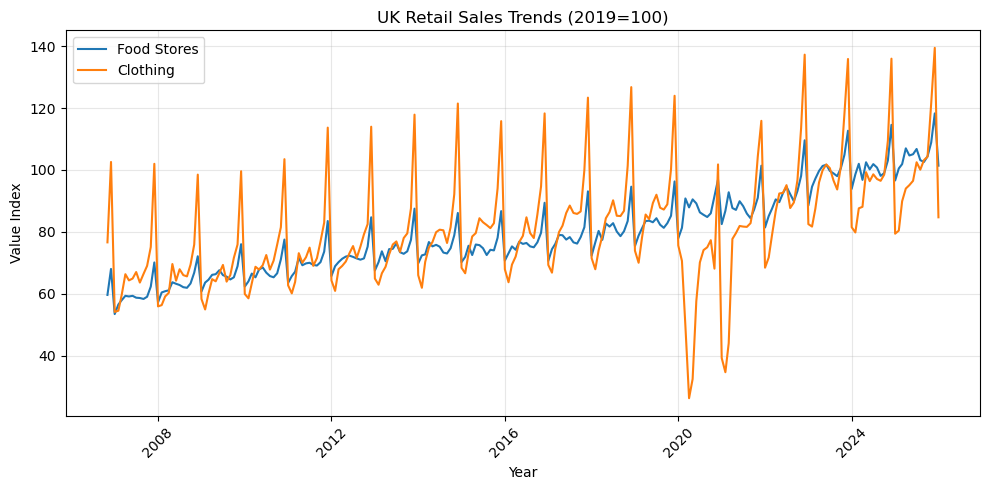

In [37]:
mplot.figure(figsize=(10,5))
mplot.plot(df_monthly['Date'], df_monthly['Food_Stores'], label='Food Stores')
mplot.plot(df_monthly['Date'], df_monthly['Clothing_Footwear'], label='Clothing')
mplot.title('UK Retail Sales Trends (2019=100)')
mplot.xlabel('Year')
mplot.ylabel('Value Index')
mplot.xticks(rotation=45)
mplot.legend()
mplot.grid(True, alpha=0.3)
mplot.tight_layout()
mplot.savefig('sales_over_time.jpeg')

Comparing the latest data i.e last month by categories

In [21]:
last_month = df_monthly.iloc[-1]
last_month

Period                          2026 JAN
Food_Stores                        101.4
Clothing_Footwear                   84.7
Household_Goods                     97.7
Internet_Share                      28.9
Date                 2026-01-01 00:00:00
Name: 652, dtype: object

In [24]:
categories = ['Food_Stores', 'Clothing_Footwear', 'Household_Goods']
values = [last_month[cat] for cat in categories]
values

[101.4, 84.7, 97.7]

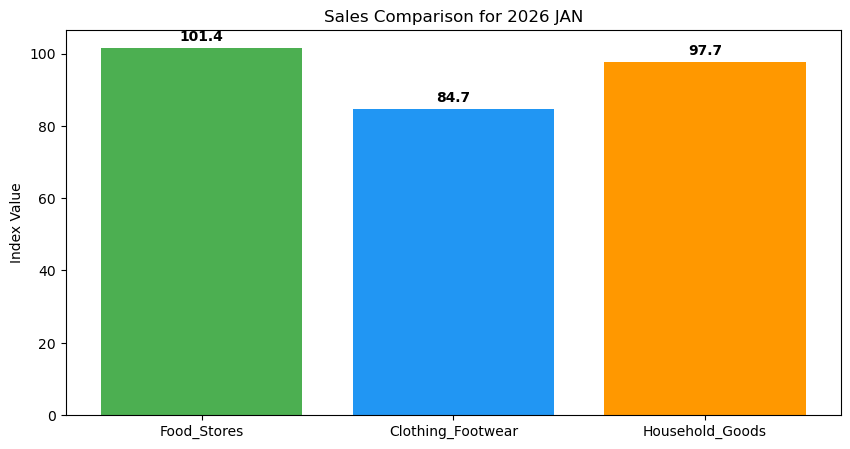

In [38]:
mplot.figure(figsize=(10, 5))
data=mplot.bar(categories, values, color=['#4CAF51', '#2196F3', '#FF9800'])
mplot.title(f'Sales Comparison for {last_month["Period"]}')
mplot.ylabel('Index Value')
mplot.bar_label(data, padding=3, fmt='%.1f', fontsize=10, fontweight='bold');
mplot.savefig('Latest_category_comparison.jpeg')

Comparision of in-store and online shares by using pie chart for latest month

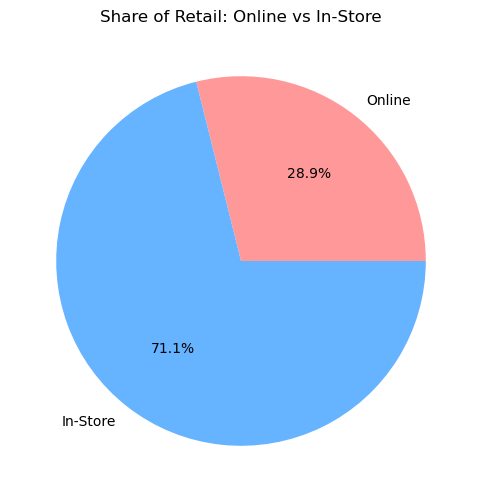

In [62]:
latest_share = df_monthly['Internet_Share'].iloc[-1]

mplot.figure(figsize=(6, 6))
mplot.pie([latest_share, 100-latest_share], labels=['Online', 'In-Store'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
mplot.title('Share of Retail: Online vs In-Store');
mplot.savefig('online_share_pie.jpeg')

Writing a short summary 

In [63]:
with open('summary.txt', 'w') as f:
    f.write("RETAIL SALES SUMMARY\n")
    f.write("====================\n")
    f.write(f"Latest Month Analyzed: {df_monthly['Period'].iloc[-1]}\n")
    f.write(f"Average Food Index: {df_monthly['Food_Stores'].mean():.2f}\n")
    f.write(f"Current Online Shopping Share: {latest_share}%\n")